# **Classifier**
## **Data Loading**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
from scipy.stats import kurtosis, skew

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, adjusted_rand_score, silhouette_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, roc_auc_score, classification_report
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from time import time

In [3]:
mutation = pd.read_csv('OmicsSomaticMutations.csv')
expression = pd.read_csv('OmicsExpressionProteinCodingGenesTPMLogp1.csv')

expression = expression.rename(columns={'Unnamed: 0': 'ModelID'})
mutation = mutation[mutation.HugoSymbol == 'TP53'] # filter for TP53 mutations

expression['Mutation'] = expression['ModelID'].isin(mutation['ModelID']).astype(int) 
expression = expression.set_index('ModelID')
# here we only consider whether there is mutation or not

/var/folders/bm/yxd_5px52t5d6m_z9t3mp9400000gn/T/ipykernel_8768/2899981484.py:1: DtypeWarning: Columns (22,50,56,57,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation = pd.read_csv('OmicsSomaticMutations.csv')


Description of the collected data:
- Gene expression TPM values of the protein coding genes for DepMap cell lines.
- Values are inferred from RNA-seq data using RSEM (unstranded mode), and are reported after log2 transformation, using a pseudo-count of 1; log2(TPM+1).


## **EDA**

In [4]:
expression.head()

,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,H3C3 (8352),AC098582.1 (8916),DUS4L-BCAP29 (115253422),C8orf44-SGK3 (100533105),ELOA3B (728929),NPBWR1 (2831),ELOA3D (100506888),ELOA3 (162699),CDR1 (1038),Mutation
ModelID,,,,,,,,,,,,,,,,,,,,,
ACH-001113,4.331992,0.000000,7.364660,2.792855,4.471187,0.028569,1.226509,3.044394,6.500005,4.739848,...,0.189034,0.201634,2.130931,0.555816,0.0,0.275007,0.0,0.0,0.000000,1
ACH-001289,4.567424,0.584963,7.106641,2.543496,3.504620,0.000000,0.189034,3.813525,4.221877,3.481557,...,1.049631,0.321928,1.464668,0.632268,0.0,0.014355,0.0,0.0,0.000000,0
ACH-001339,3.150560,0.000000,7.379118,2.333424,4.228049,0.056584,1.310340,6.687201,3.682573,3.273516,...,1.097611,0.831877,2.946731,0.475085,0.0,0.084064,0.0,0.0,0.042644,1
ACH-001979,4.240314,0.000000,5.681168,2.063503,1.641546,0.000000,7.236301,5.948367,4.596935,2.918386,...,0.000000,0.847997,1.887525,0.176323,0.0,0.000000,0.0,0.0,0.000000,0
ACH-002438,4.032101,0.000000,6.674687,2.117695,3.003602,0.000000,2.169925,6.838195,3.253989,4.276497,...,0.378512,0.584963,1.748461,0.839960,0.0,0.014355,0.0,0.0,0.042644,0


We have cell lines as rows and genes as columns. Each entry represents the gene count. 

Entries are not integers which makes sense since the data comes from a log2 transformation.

In [5]:
expression.shape

(1673, 19194)

We have 1673 cell lines and more than 19k genes

In [6]:
expression[expression.duplicated()]


,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,H3C3 (8352),AC098582.1 (8916),DUS4L-BCAP29 (115253422),C8orf44-SGK3 (100533105),ELOA3B (728929),NPBWR1 (2831),ELOA3D (100506888),ELOA3 (162699),CDR1 (1038),Mutation
ModelID,,,,,,,,,,,,,,,,,,,,,


There are no duplicates.

In [7]:
expression.describe()

,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,H3C3 (8352),AC098582.1 (8916),DUS4L-BCAP29 (115253422),C8orf44-SGK3 (100533105),ELOA3B (728929),NPBWR1 (2831),ELOA3D (100506888),ELOA3 (162699),CDR1 (1038),Mutation
count,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000,...,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000,1673.000000
mean,3.364755,0.084035,6.511230,2.351832,3.621073,0.431686,2.231446,5.104079,4.561802,4.005777,...,0.750993,0.491338,2.059848,0.405048,0.016839,0.264674,0.017209,0.023767,0.063297,0.589360
std,1.646095,0.421914,0.650400,0.544043,0.834547,1.216362,2.303087,1.840251,1.149210,0.759120,...,0.777924,0.375643,0.686985,0.367234,0.052869,0.592130,0.060571,0.078146,0.184181,0.492097
min,0.000000,0.000000,3.117695,0.594549,0.056584,0.000000,0.000000,0.000000,1.157044,0.815575,...,0.000000,0.000000,0.263034,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.873813,0.000000,6.104127,1.992768,3.158660,0.014355,0.124328,4.657640,3.855990,3.529821,...,0.000000,0.214125,1.580145,0.124328,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.808385,0.000000,6.503190,2.327687,3.704872,0.042644,1.321928,5.653920,4.463361,3.996389,...,0.555816,0.422233,2.017922,0.333424,0.000000,0.014355,0.000000,0.000000,0.000000,1.000000
75%,4.426936,0.000000,6.928370,2.653060,4.165108,0.150560,4.099295,6.275380,5.190615,4.466627,...,1.195348,0.687061,2.503349,0.594549,0.000000,0.189034,0.000000,0.014355,0.000000,1.000000
max,8.132680,7.814422,9.175250,4.747387,5.972463,8.014299,9.693016,8.633068,9.581991,7.434211,...,4.894818,3.109361,4.433627,2.247928,0.622930,4.254745,0.992768,1.056584,1.867896,1.000000


For the first genes the count is 1673: this suggests that we don't have missing values, which will be checked more precisely later.
The fact that the minimum seems to always be zero suggests that each gene is not expressed in at least some cells. Not all minima are always zero, suggesting that some genes are expressed in all cell lines.

In [8]:
min_values = expression.drop(columns='Mutation').select_dtypes(include='number').min()
count = (min_values != 0).sum()

print(f'Number of genes expressed in every cell line is {count}')

Number of genes expressed in every cell line is 7501


In [9]:
column_means = expression.drop(columns='Mutation').select_dtypes(include='number').mean()

sorted_means = column_means.sort_values(ascending=False)

sorted_means.head(10)

MT-ATP8 (4509)    15.140921
MT-CO2 (4513)     14.099633
MT-CO3 (4514)     13.697018
MT-CO1 (4512)     13.583278
MT-ND4L (4539)    13.567608
MT-ATP6 (4508)    13.083638
EEF1A1 (1915)     13.076830
MT-ND3 (4537)     12.960574
MT-ND4 (4538)     12.851867
RPS18 (6222)      12.624594
dtype: float64

Most expressed genes are the mithocondrial genes which makes sense since in general they are highly expressed.

In [10]:
expression.isna().sum().sum()

np.int64(0)

No missing values.

0.17567554016836673


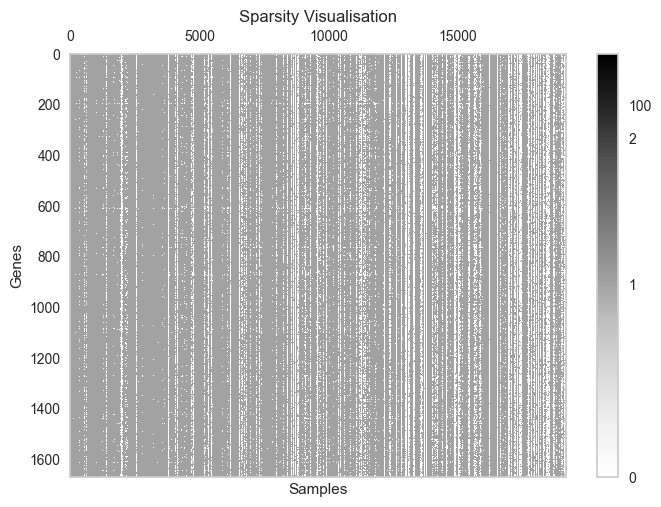

In [11]:
sparsity_index_unfiltered = 1 - (np.count_nonzero(expression.values) / expression.size)
print(sparsity_index_unfiltered)

class MidpointNormalize(colors.Normalize):
    def __init__(self, vmin=None, vmax=None, vcenter=None, clip=False):
        self.vcenter = vcenter
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x, y = [self.vmin, self.vcenter, self.vmax], [0, 0.8, 1.]
        return np.ma.masked_array(np.interp(value, x, y,
                                            left=-np.inf, right=np.inf))

    def inverse(self, value):
        y, x = [self.vmin, self.vcenter, self.vmax], [0, 0.8, 1]
        return np.interp(value, x, y, left=-np.inf, right=np.inf)


fig, ax = plt.subplots()
midnorm = MidpointNormalize(vmin=0, vcenter=1.75, vmax=250)

graph_temporary = plt.spy(expression, aspect = "auto", norm=midnorm,
                   cmap='Greys') #hsv
plt.colorbar(graph_temporary).set_ticks([0, 1, 2, 100])
plt.grid(False)
plt.xlabel("Samples")
plt.ylabel("Genes")
ax.set_title('Sparsity Visualisation')

plt.show()

Dataset not sparse! Now we'll see which are the least and the most expressed genes.

In [12]:
# which is the gene that is expressed less
min_expressed_gene = expression.sum(axis = 0).idxmin()
print("Least expressed gene: {}\nNumber of codifying samples: {}".format(min_expressed_gene, expression.sum(axis = 0)[min_expressed_gene]))

# which is the gene that is expressed most
max_expressed_gene = expression.sum(axis = 0).idxmax()
print("\nMost expressed gene: {}\nNumber of codifying samples: {}".format(max_expressed_gene, expression.sum(axis = 0)[max_expressed_gene]))


Least expressed gene: CDY1B (253175)
Number of codifying samples: 0.01435529297707

Most expressed gene: MT-ATP8 (4509)
Number of codifying samples: 25330.760445912758


**CDY1B**: generally expressed in the male population


In [13]:
# SKEWNESS & KURTOSIS
train_flattened = pd.Series(expression.values.flatten())
skew_matrix = skew(train_flattened)
kurtosis_matrix = kurtosis(train_flattened)
print("Skewness of the whole matrix: ", round(skew_matrix))
print("Kurtosis of the whole matrix: ", round(kurtosis_matrix))


Skewness of the whole matrix:  1
Kurtosis of the whole matrix:  0


Distribution is almost normal which makes sense since our data has been normalized.

In [14]:
def inverse_log2_transform(transformed_data):
    original_data = (2 ** transformed_data) - 1
    
    return original_data

In [15]:
original_data = inverse_log2_transform(expression.drop(columns='Mutation'))

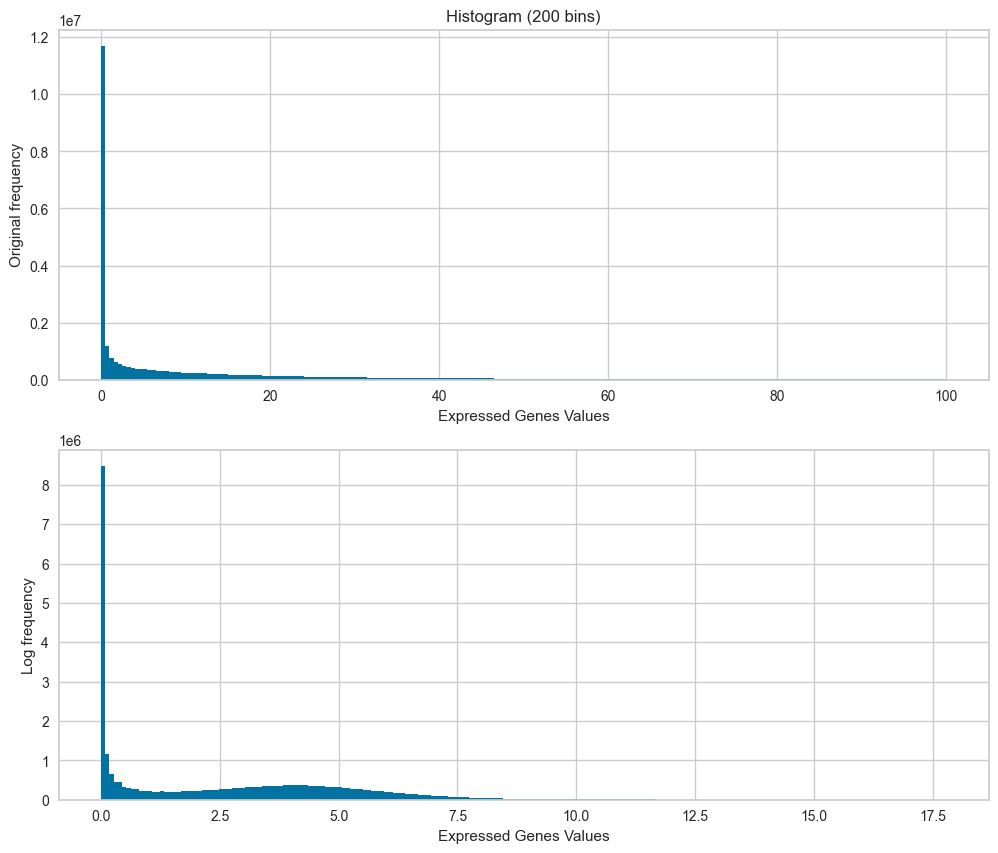

In [16]:
# distribution of the whole data
flattened = pd.Series(expression.values.flatten())
original_flattened = pd.Series(original_data.values.flatten())
fig, ax = plt.subplots(2, 1, figsize=(12, 10)) 
ax[0].hist(original_flattened, range = [0, 100], bins = 200)
ax[0].set_xlabel("Expressed Genes Values")
ax[0].set_ylabel("Original frequency")
ax[0].set_title("Histogram (200 bins)")

ax[1].hist(flattened, bins = 200)
ax[1].set_xlabel("Expressed Genes Values")
ax[1].set_ylabel("Log frequency")
plt.show()

In [52]:
mutated = expression[expression['Mutation'] == 1]
non_mutated = expression[expression['Mutation'] == 0]

print("Number of mutated cells:", len(mutated))
print("Number of non mutated cells:", len(non_mutated))

print(f'Percentage of mutated cells: {round(len(mutated)/1673*100)}%')
print(f'Percentage of non mutated cells: {round(len(non_mutated)/1673*100)}%')


Number of mutated cells: 986
Number of non mutated cells: 687
Percentage of mutated cells: 59%
Percentage of non mutated cells: 41%


## **Dimensionality Reduction**

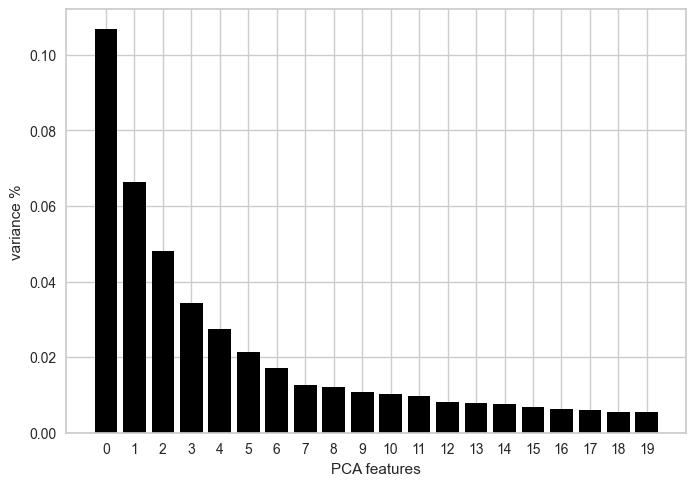

In [5]:
# PCA
expression_scaled = pd.DataFrame(StandardScaler().fit_transform(expression), columns=expression.columns)
	
pca = PCA(n_components=20)
principalComponents = pca.fit_transform(expression_scaled)

features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_ratio_, color='black')
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.xticks(features)

PCA_components = pd.DataFrame(principalComponents)

explained_variances = pca.explained_variance_ratio_
explained_variances_percentage = explained_variances * 100

cumulative_variances = np.cumsum(explained_variances)
cumulative_variances_percentage = cumulative_variances * 100

In [8]:
X = expression

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)  
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.10673662 0.06622514 0.04807285]


/var/folders/bm/yxd_5px52t5d6m_z9t3mp9400000gn/T/ipykernel_4850/2872959061.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=expression.Mutation, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', 10))


Text(0, 0.5, 'component 2')

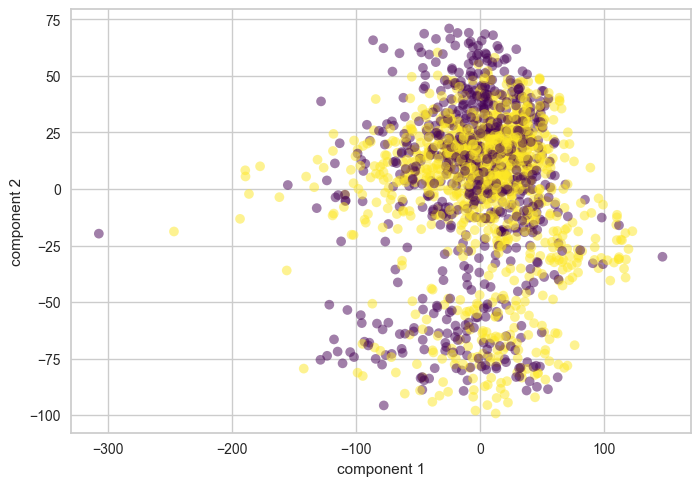

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=expression.Mutation, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', 10))
plt.xlabel('component 1')
plt.ylabel('component 2')

/var/folders/bm/yxd_5px52t5d6m_z9t3mp9400000gn/T/ipykernel_4850/1743643603.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=expression.Mutation)


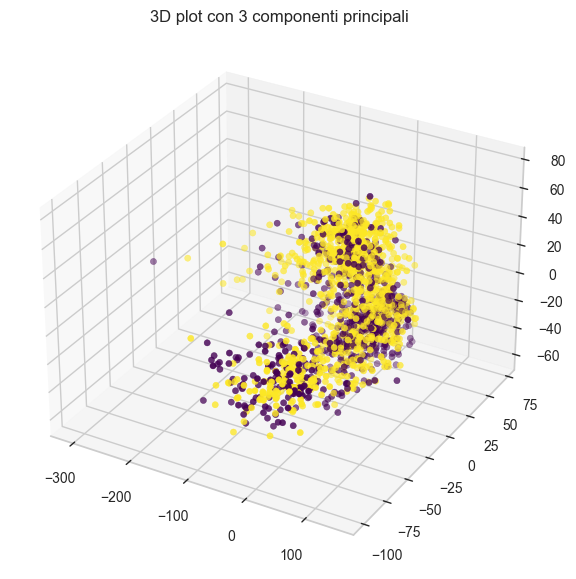

In [ ]:
x=X_pca[:, 0]
y=X_pca[:, 1]
z=X_pca[:, 2]
fig= plt.figure(figsize= (10, 7))
ax = plt.axes(projection="3d")

ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=expression.Mutation)
plt.title("3D plot con 3 componenti principali")
plt.show()

From these plots we see that in 2 and 3 dimensions there is no clear distinction between the two classes.

## **Clustering**

We try to see whether clustering identifies two different classes correspondig to mutated and not.

Cluster labels were flipped to match true labels

Confusion Matrix:
[[261 426]
 [301 685]]

Accuracy: 0.5655
Adjusted Rand Index: 0.0132
Silhouette Score: 0.0626

PCA explained variance: [0.10674164 0.06622847]


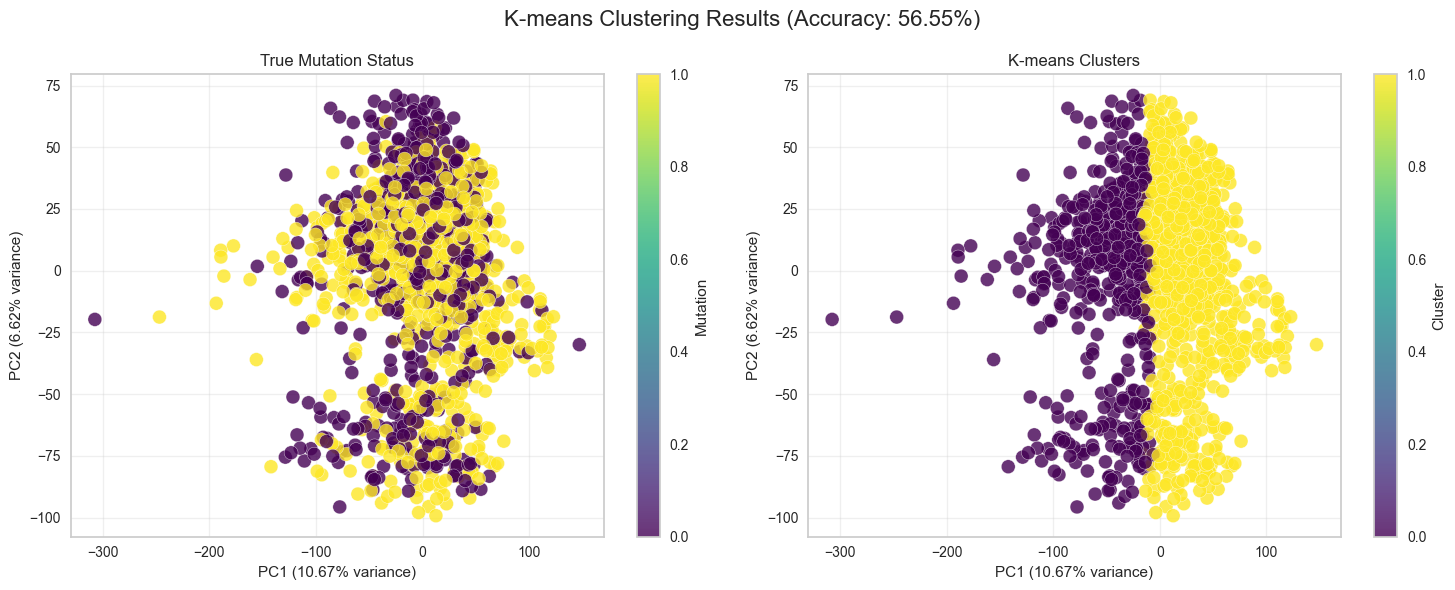

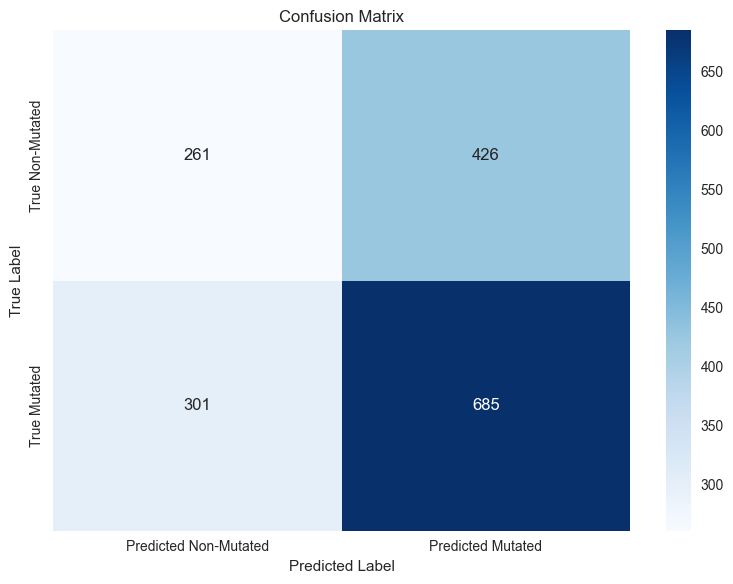

In [ ]:
mutation_column = 'Mutation' 

X = expression.drop(columns=[mutation_column])
y_true = expression[mutation_column].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

accuracy_normal = accuracy_score(y_true, y_pred)
accuracy_flipped = accuracy_score(y_true, 1 - y_pred)

if accuracy_flipped > accuracy_normal:
    print("Cluster labels were flipped to match true labels")
    y_pred = 1 - y_pred
    accuracy = accuracy_flipped
else:
    accuracy = accuracy_normal

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

ari = adjusted_rand_score(y_true, y_pred)
silhouette = silhouette_score(X_scaled, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA explained variance: {pca.explained_variance_ratio_}")

plt.figure(figsize=(15, 6))

# plot 1: True mutation status
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', 
            alpha=0.8, edgecolors='w', s=100)
plt.title('True Mutation Status')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(label='Mutation')
plt.grid(alpha=0.3)

# plot 2: K-means clusters
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='viridis', 
            alpha=0.8, edgecolors='w', s=100)
plt.title('K-means Clusters')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(label='Cluster')
plt.grid(alpha=0.3)

plt.suptitle(f'K-means Clustering Results (Accuracy: {accuracy:.2%})', fontsize=16)
plt.tight_layout()
plt.show()

# confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Non-Mutated', 'Predicted Mutated'],
            yticklabels=['True Non-Mutated', 'True Mutated'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## **Outliers**

In this section, we identify outliers and deal with them.

First, we standardize the data

In [ ]:
df = expression.drop(columns='Mutation')
print(f"DataFrame shape: {df.shape}")

print("Standardizing data...")
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    index=df.index
)

DataFrame shape: (1673, 19193)
Standardizing data...


Then, we consider only the most relevant 500 components detected by PCA (since otherwise the data has too many features).

In [ ]:
print("Performing PCA to reduce dimensions...")
pca = PCA(n_components=500)
df_pca = pd.DataFrame(
    pca.fit_transform(df_scaled),
    index=df.index
)
print(f"Explained variance with 500 PCs: {sum(pca.explained_variance_ratio_):.2%}")

Performing PCA to reduce dimensions...
Explained variance with 500 PCs: 83.08%


Now we detect outliers as follows:
1. isolation forest: this method builds an ensemble of random trees and tries to isolate data points. Anomalies (outliers) are isolated quicker (i.e., fewer splits are needed to isolate them) because they are more distinct, thus, the average path length from the root to the data point is used to compute an anomaly score (and points with shorter average path lengths are more likely to be outliers)
2. calculate statistics of each row and detect outliers on summary statistics
3. Mahalanobis distance on PCA components

Finally, we combine these approaches and define as outliers the points detected by at least 2 out of 3 methods.

In [ ]:
print("Detecting outliers using Isolation Forest on PCA data...")
iso_forest_pca = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # assumes 5% outliers
    random_state=42,
    n_jobs=-1 
)
outlier_labels_pca = iso_forest_pca.fit_predict(df_pca)
outliers_pca = outlier_labels_pca == -1

Detecting outliers using Isolation Forest on PCA data...


In [ ]:
print("Calculating statistical summaries for each row...")
row_stats = pd.DataFrame(index=df.index)
row_stats['mean'] = df.mean(axis=1)
row_stats['std'] = df.std(axis=1)
row_stats['median'] = df.median(axis=1)
row_stats['mad'] = abs(df.subtract(df.median(axis=1), axis=0)).median(axis=1)  
row_stats['skew'] = df.skew(axis=1)
row_stats['kurt'] = df.kurtosis(axis=1)
row_stats['zero_count'] = (df == 0).sum(axis=1)
row_stats['zero_pct'] = row_stats['zero_count'] / df.shape[1]

Calculating statistical summaries for each row...


In [ ]:
print("Detecting outliers using Isolation Forest on summary statistics...")
iso_forest_stats = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # 5% outliers
    random_state=42
)
outlier_labels_stats = iso_forest_stats.fit_predict(row_stats)
outliers_stats = outlier_labels_stats == -1

Detecting outliers using Isolation Forest on summary statistics...


In [ ]:
print("Calculating Mahalanobis distances...")
def mahalanobis_distances(X):
    mean_vec = np.mean(X, axis=0)
    cov_mat = np.cov(X, rowvar=False)
    
    inv_covmat = np.linalg.inv(cov_mat)
    distances = []
    
    for i in range(X.shape[0]):
        x = X[i]
        dist = np.sqrt(np.dot(np.dot((x - mean_vec), inv_covmat), (x - mean_vec).T))
        distances.append(dist)
        
    return np.array(distances)

mahalanobis_dist = mahalanobis_distances(df_pca.values)

# define outliers as points with distance > 3 standard deviations from mean
mean_dist = np.mean(mahalanobis_dist)
std_dist = np.std(mahalanobis_dist)
threshold = mean_dist + 3 * std_dist
outliers_mahalanobis = mahalanobis_dist > threshold

Calculating Mahalanobis distances...


In [ ]:
combined_outliers = (outliers_pca.astype(int) + 
                     outliers_stats.astype(int) + 
                     outliers_mahalanobis.astype(int)) >= 2

outlier_summary = pd.DataFrame({
    'Isolation Forest (PCA)': outliers_pca,
    'Isolation Forest (Stats)': outliers_stats,
    'Mahalanobis Distance': outliers_mahalanobis,
    'Combined (≥2 methods)': combined_outliers
}, index=df.index)

print("\nOutlier Detection Results:")
print(f"Isolation Forest on PCA components: {sum(outliers_pca)} outliers")
print(f"Isolation Forest on row statistics: {sum(outliers_stats)} outliers")
print(f"Mahalanobis distance: {sum(outliers_mahalanobis)} outliers")
print(f"Combined approach (≥2 methods): {sum(combined_outliers)} outliers")

outlier_indices = df.index[combined_outliers]
print(f"\nIndices of outlier rows: {outlier_indices.tolist()}")


Outlier Detection Results:
Isolation Forest on PCA components: 84 outliers
Isolation Forest on row statistics: 84 outliers
Mahalanobis distance: 0 outliers
Combined approach (≥2 methods): 6 outliers

Indices of outlier rows: ['ACH-001119', 'ACH-001134', 'ACH-000514', 'ACH-000870', 'ACH-001642', 'ACH-000904']



Creating visualizations...


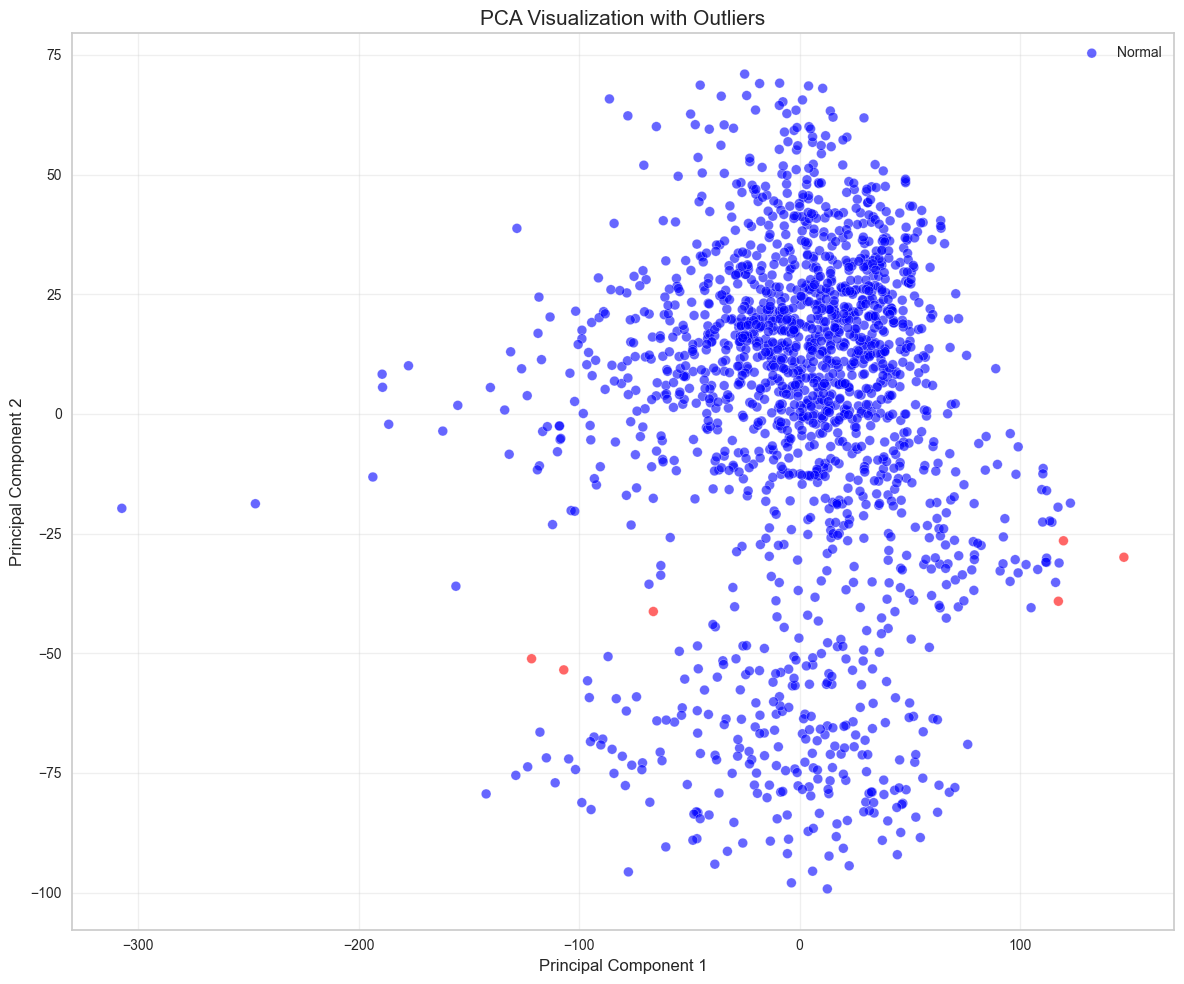

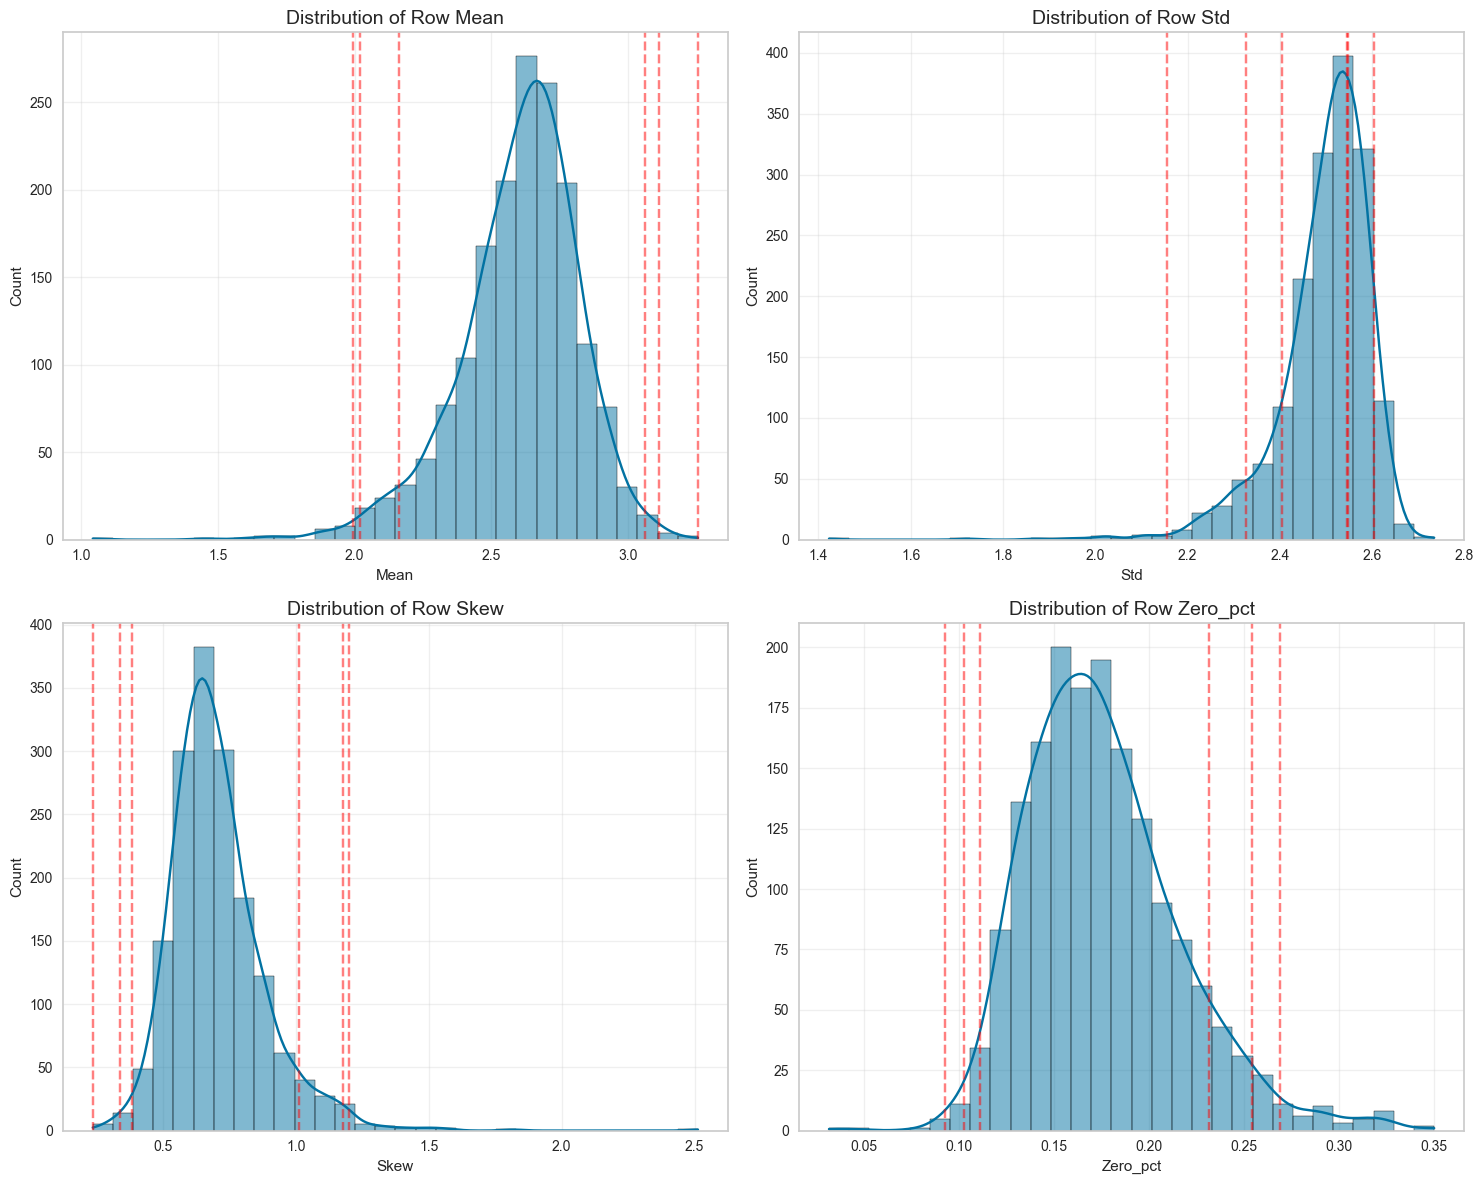

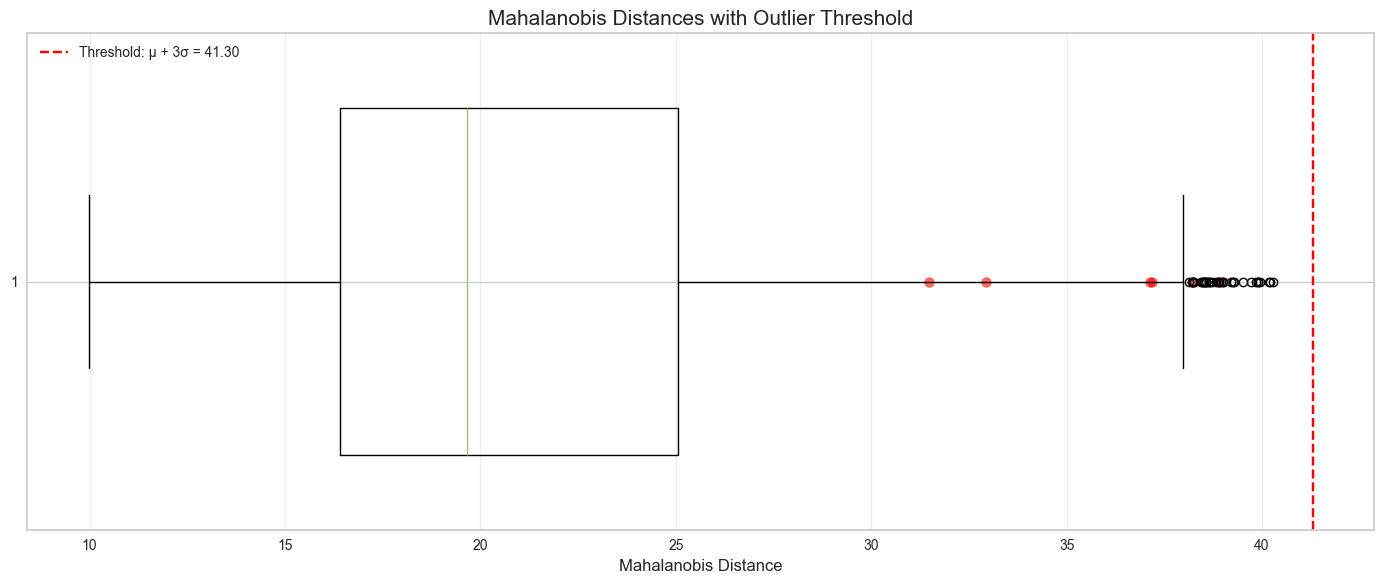


Analysis complete. Outlier rows have been identified.
Full results saved to outlier_detection_results.csv


In [ ]:
print("\nCreating visualizations...")

plt.figure(figsize=(12, 10))
plt.scatter(
    df_pca.iloc[:, 0], 
    df_pca.iloc[:, 1], 
    c=['red' if x else 'blue' for x in combined_outliers], 
    alpha=0.6,
    edgecolors='w'
)
plt.title('PCA Visualization with Outliers', fontsize=15)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(['Normal', 'Outlier'])
plt.tight_layout()
plt.savefig('pca_outliers.png', dpi=300)
plt.show()

stats_to_plot = ['mean', 'std', 'skew', 'zero_pct']
plt.figure(figsize=(15, 12))

for i, stat in enumerate(stats_to_plot):
    plt.subplot(2, 2, i+1)
    sns.histplot(row_stats[stat], bins=30, kde=True)
    
    # Mark outlier values with vertical lines
    for value in row_stats.loc[combined_outliers, stat]:
        plt.axvline(x=value, color='red', linestyle='--', alpha=0.5)
    
    plt.title(f'Distribution of Row {stat.capitalize()}', fontsize=14)
    plt.xlabel(stat.capitalize())
    plt.ylabel('Count')
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('row_statistics.png', dpi=300)
plt.show()

plt.figure(figsize=(14, 6))
plt.boxplot(mahalanobis_dist, vert=False, widths=0.7)
plt.axvline(x=threshold, color='red', linestyle='--', 
            label=f'Threshold: μ + 3σ = {threshold:.2f}')
plt.scatter(
    mahalanobis_dist[combined_outliers], 
    np.ones_like(mahalanobis_dist[combined_outliers]),
    color='red', alpha=0.6, s=50
)
plt.title('Mahalanobis Distances with Outlier Threshold', fontsize=15)
plt.xlabel('Mahalanobis Distance', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('mahalanobis_distances.png', dpi=300)
plt.show()

outlier_summary['row_index'] = df.index
outlier_summary.to_csv('outlier_detection_results.csv', index=False)

print("\nAnalysis complete. Outlier rows have been identified.")
print("Full results saved to outlier_detection_results.csv")

In [16]:
non_outlier_mask = ~df.index.isin(outlier_indices)

cleaned_df = expression.loc[non_outlier_mask]

print(f"Original dataframe shape: {df.shape}")
print(f"Removed {len(outlier_indices)} outlier rows")
print(f"Cleaned dataframe shape: {cleaned_df.shape}")

Original dataframe shape: (1673, 19193)
Removed 6 outlier rows
Cleaned dataframe shape: (1667, 19194)


## **Classifiers** 

Once we have a clear understanding of the data and we have cleaned it as much as possible, we can try and build a predictor of the mutation of TP53.

### **Step 1**
First, we try and classify on the whole dataset. We try several models:
- logistic regression
- random forest (ensemble of decision trees)
- gradient boosting (ensemble of decision trees where each new tree corrects the errors of the previous ones)
- svm (finds the optimal hyperplane that maximizes the margin between classes)
- knn 
- neural network

In [27]:
mutation_column = 'Mutation'  

X = cleaned_df.drop(columns=[mutation_column])
y = cleaned_df[mutation_column].values

print(f"Class distribution: {np.bincount(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Class distribution: [685 983]


We compare different models using the following metrics:
- accuracy: proportion of correctly predicted samples
- precision: proportion of positive predictions that are actually correct
- recall: proportion of negative predictions that are actually correct
- F1 score: harmonic mean of Precision and Recall
- ROC AUC score: ability of the classifier to distinguish between classes
- PR AUC: trade-off between Precision and Recall across thresholds (focuses on performance for the positive class)

Class distribution: [685 983]

Training Logistic Regression...
Accuracy: 0.8441
Precision: 0.8521
Recall: 0.8902
F1 Score: 0.8708
ROC AUC: 0.9071
PR AUC: 0.9041

Training Random Forest...
Accuracy: 0.7842
Precision: 0.7847
Recall: 0.8740
F1 Score: 0.8269
ROC AUC: 0.8634
PR AUC: 0.8711

Training Gradient Boosting...
Accuracy: 0.8633
Precision: 0.8621
Recall: 0.9146
F1 Score: 0.8876
ROC AUC: 0.9218
PR AUC: 0.9257

Training Support Vector Machine...
Accuracy: 0.8082
Precision: 0.7964
Recall: 0.9065
F1 Score: 0.8479
ROC AUC: 0.8871
PR AUC: 0.8960

Training K-Nearest Neighbors...
Accuracy: 0.7218
Precision: 0.7686
Recall: 0.7561
F1 Score: 0.7623
ROC AUC: 0.7593
PR AUC: 0.7705

Training Neural Network...
Accuracy: 0.8225
Precision: 0.8386
Recall: 0.8659
F1 Score: 0.8520
ROC AUC: 0.8703
PR AUC: 0.8735

All model metrics:
                        Accuracy  Precision    Recall  F1 Score   ROC AUC  \
Logistic Regression     0.844125   0.852140  0.890244  0.870775  0.907146   
Random Forest       

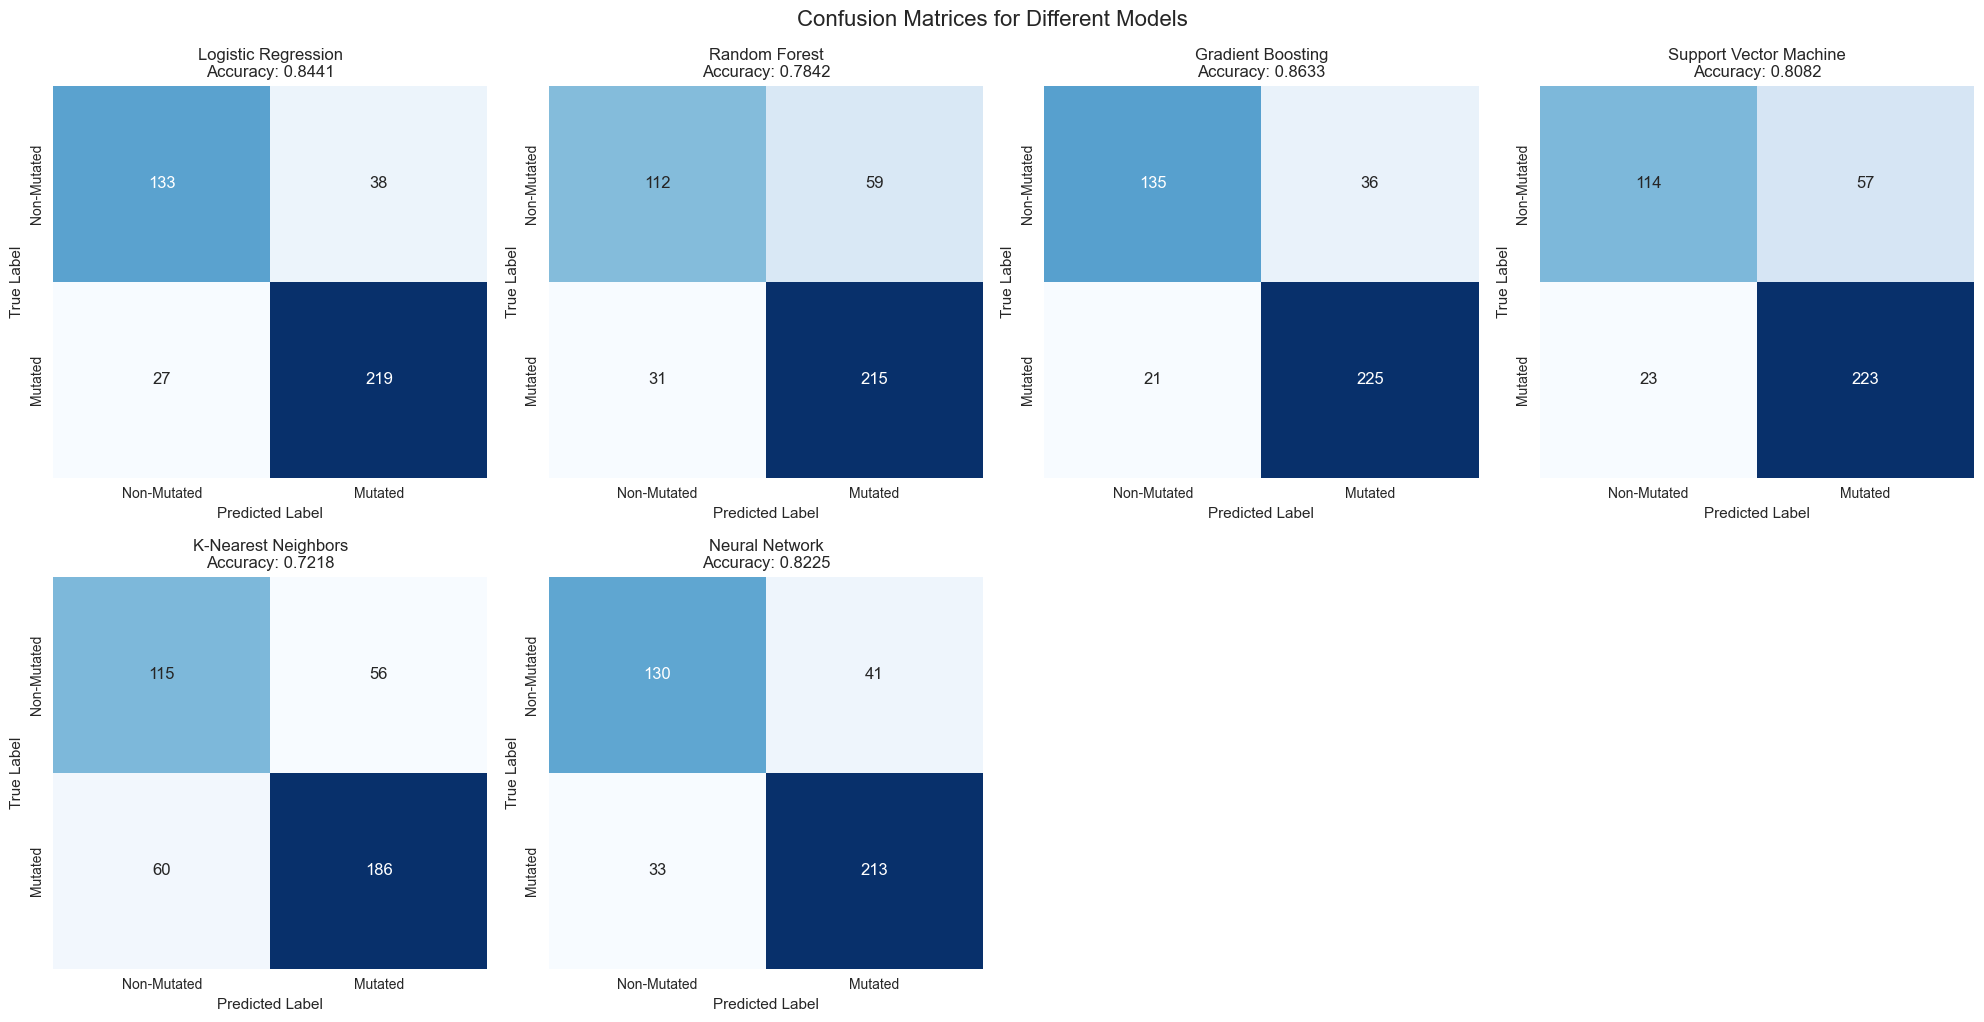

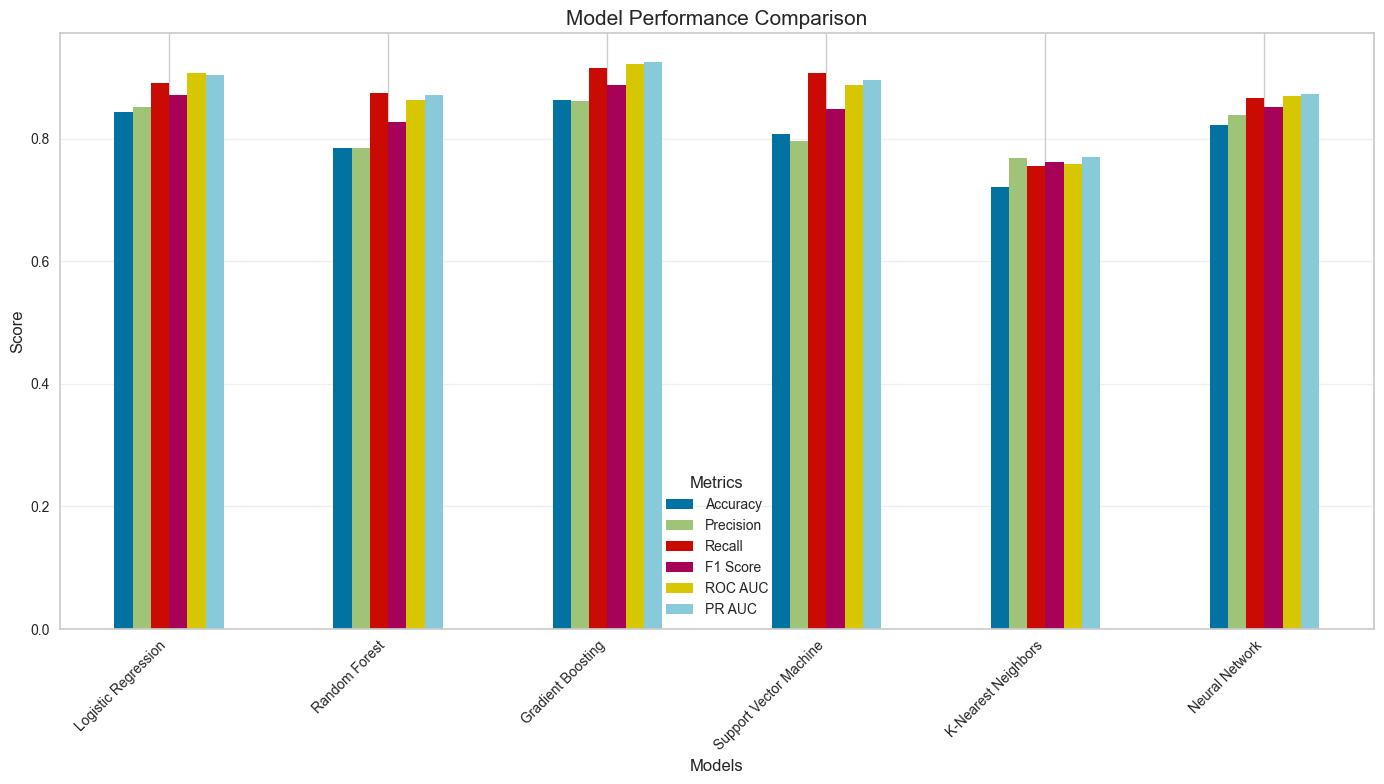

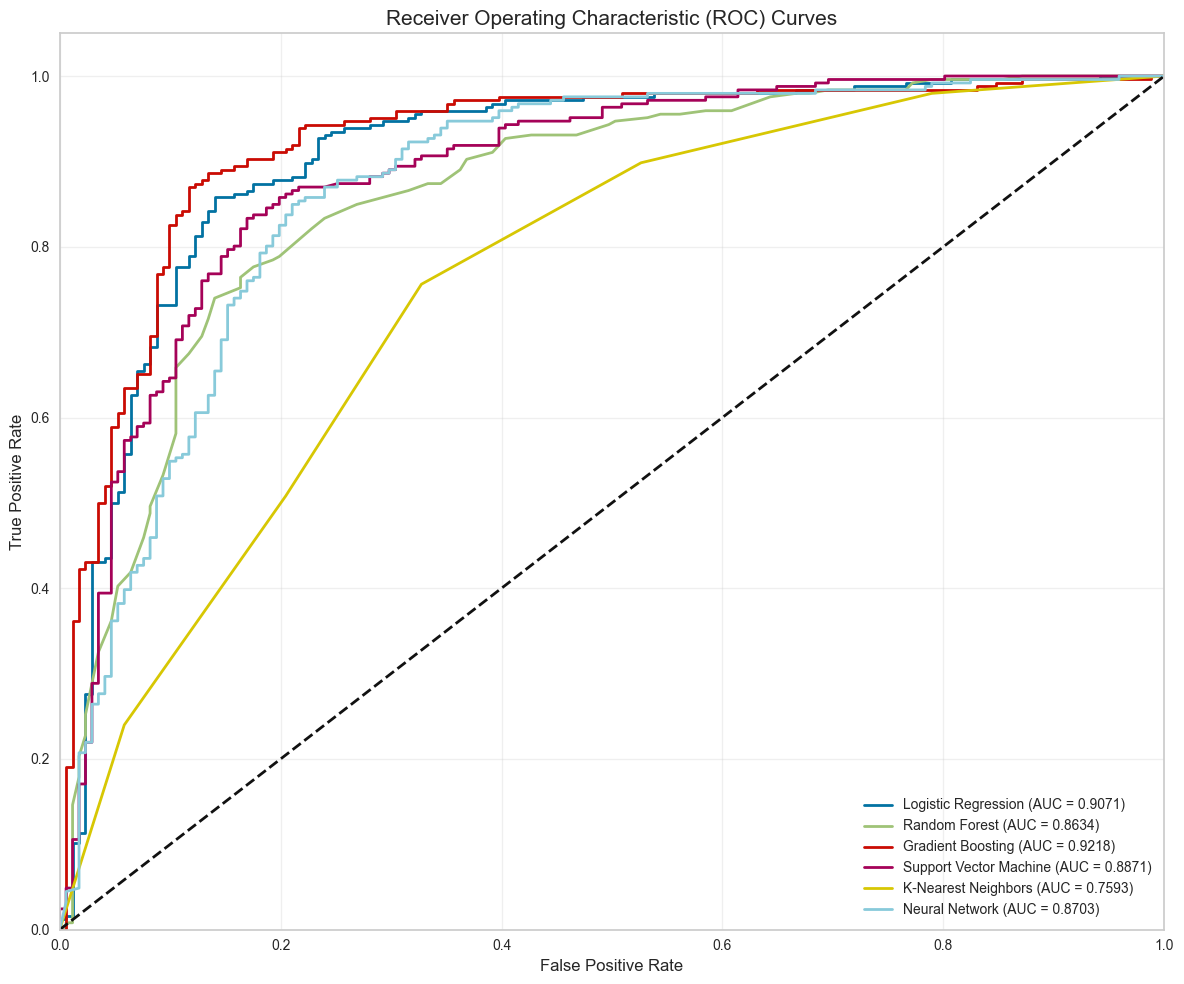

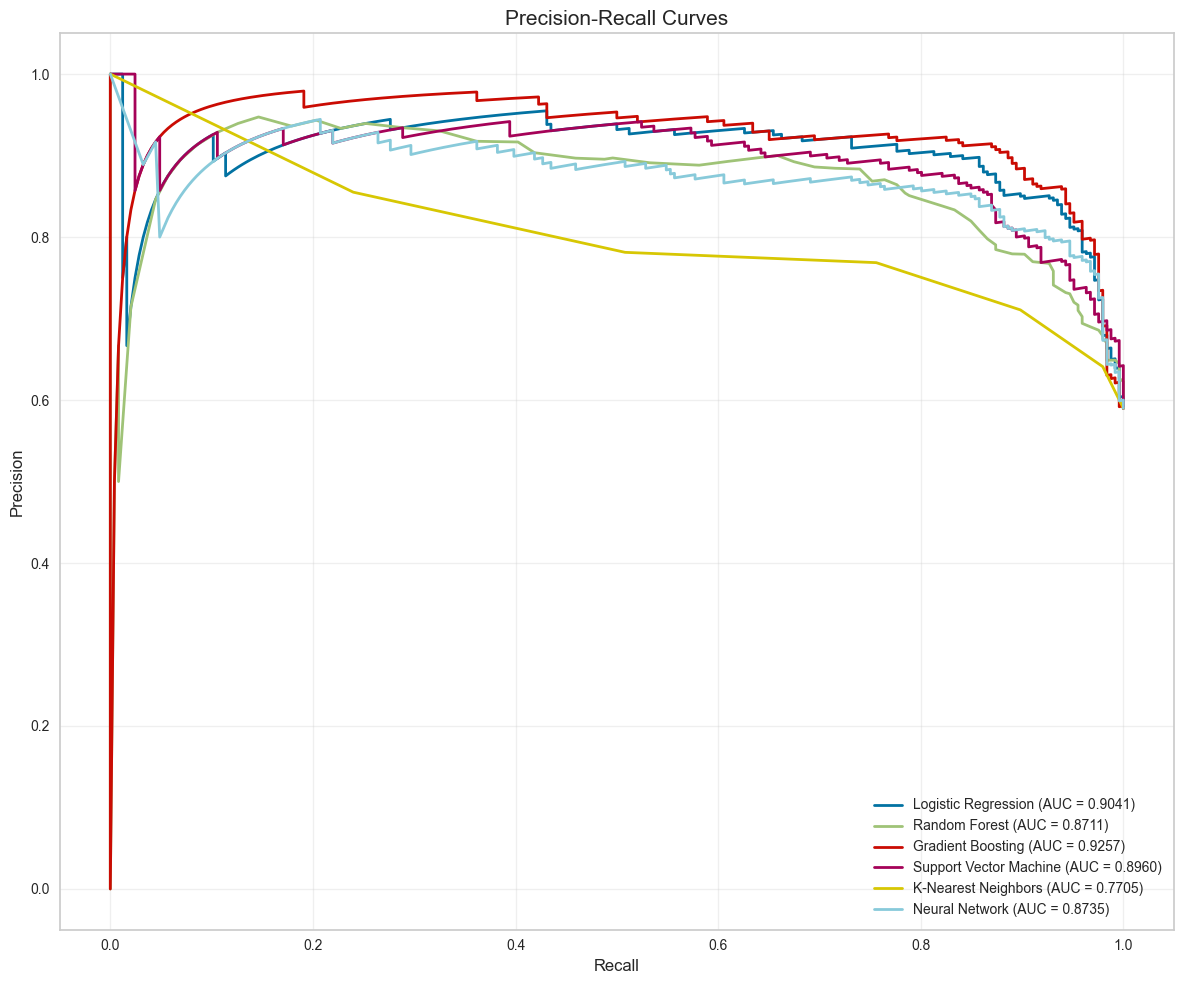


Best models by metric:
Accuracy: Gradient Boosting (0.8633)
Precision: Gradient Boosting (0.8621)
Recall: Gradient Boosting (0.9146)
F1 Score: Gradient Boosting (0.8876)
ROC AUC: Gradient Boosting (0.9218)
PR AUC: Gradient Boosting (0.9257)


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Neural Network': MLPClassifier(max_iter=1000, random_state=42),
}

all_predictions = {}
model_metrics = {
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'ROC AUC': [],
    'PR AUC': []
}
model_names = []
confusion_matrices = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    all_predictions[name] = y_pred
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:  
        y_proba = model.decision_function(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC AUC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Precision-Recall AUC
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    
    model_names.append(name)
    model_metrics['Accuracy'].append(acc)
    model_metrics['Precision'].append(prec)
    model_metrics['Recall'].append(rec)
    model_metrics['F1 Score'].append(f1)
    model_metrics['ROC AUC'].append(roc_auc)
    model_metrics['PR AUC'].append(pr_auc)
    
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[name] = cm
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")

metrics_df = pd.DataFrame(model_metrics, index=model_names)
print("\nAll model metrics:")
print(metrics_df)

# confusion matrices
n_models = len(models)
rows = (n_models + 3) // 4 
fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, (name, cm) in enumerate(confusion_matrices.items()):
    if i < len(axes):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
        axes[i].set_title(f'{name}\nAccuracy: {model_metrics["Accuracy"][i]:.4f}')
        axes[i].set_xlabel('Predicted Label')
        axes[i].set_ylabel('True Label')
        axes[i].set_xticklabels(['Non-Mutated', 'Mutated'])
        axes[i].set_yticklabels(['Non-Mutated', 'Mutated'])

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Confusion Matrices for Different Models', fontsize=16, y=1.02)
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'PR AUC']
metrics_df[metrics_to_plot].plot(kind='bar', figsize=(14, 8))
plt.title('Model Performance Comparison', fontsize=15)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics', loc='best')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300)
plt.show()

# ROC curves for all models
plt.figure(figsize=(12, 10))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300)
plt.show()

# Precision-Recall curves
plt.figure(figsize=(12, 10))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)
    
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    
    plt.plot(recall, precision, lw=2, label=f'{name} (AUC = {pr_auc:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=15)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=300)
plt.show()

# best model based on different metrics
best_models = {}
for metric in metrics_to_plot:
    best_idx = np.argmax(model_metrics[metric])
    best_models[metric] = model_names[best_idx]

print("\nBest models by metric:")
for metric, model in best_models.items():
    value = metrics_df.loc[model, metric]
    print(f"{metric}: {model} ({value:.4f})")

Therefore we will use Gradient Boosting as predictive model. Gradient Boosting is an ensemble learning method and it works by sequentially adding decision trees where each tree tries to improve the model's performance by focusing on the errors made by the previous trees and reducing those error with help of gradient descent. 

Parameters: https://www.geeksforgeeks.org/how-to-tune-hyperparameters-in-gradient-boosting-algorithm/

In [ ]:
param_grid = {
    'learning_rate': [0.05, 0.1],    
    'n_estimators': [100, 200],  
    'subsample': [0.8, 1.0]   
}

print("Starting focused parameter search...")
start_time = time()

best_accuracy = 0
best_params = None
results = []

for lr in param_grid['learning_rate']:
    for n_est in param_grid['n_estimators']:
        for n_sample in param_grid['subsample']:
            model = GradientBoostingClassifier(
                learning_rate=lr,
                n_estimators=n_est,
                subsample=n_sample,
                random_state=42
            )
            
            model.fit(X_train_scaled, y_train)
            y_test_pred = model.predict(X_test_scaled)
            accuracy = accuracy_score(y_test, y_test_pred)
            
            results.append({
                'params': {
                    'learning_rate': lr,
                    'n_estimators': n_est,
                    'subsample': n_sample
                },
                'accuracy': accuracy
            })
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'learning_rate': lr,
                    'n_estimators': n_est,
                    'subsample': n_sample,
                }
            
            print(f"lr={lr}, n_est={n_est}, subsample={n_sample}: accuracy={accuracy:.4f}")

results.sort(key=lambda x: x['accuracy'], reverse=True)

end_time = time()
print(f"Parameter search completed in {end_time - start_time:.2f} seconds")
print(f"Best parameters: {best_params}")
print(f"Best validation accuracy: {best_accuracy:.4f}")

final_model = GradientBoostingClassifier(**best_params, random_state=42)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.4f}")

Starting focused parameter search...
lr=0.05, n_est=100, subsample=0.8: accuracy=0.8729
lr=0.05, n_est=100, subsample=1.0: accuracy=0.8609
lr=0.05, n_est=200, subsample=0.8: accuracy=0.8753
lr=0.05, n_est=200, subsample=1.0: accuracy=0.8681
lr=0.1, n_est=100, subsample=0.8: accuracy=0.8801
lr=0.1, n_est=100, subsample=1.0: accuracy=0.8633
lr=0.1, n_est=200, subsample=0.8: accuracy=0.8825
lr=0.1, n_est=200, subsample=1.0: accuracy=0.8777
Parameter search completed in 4931.47 seconds
Best parameters: {'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.8}
Best validation accuracy: 0.8825
Test accuracy: 0.8825


Therefore our final model will be: Gradient Boosting with {'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.8}

### **Feature Importance**

In [ ]:
feature_importances = final_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,  
    'Importance': feature_importances
})

top_10_features = feature_importance_df.sort_values('Importance', ascending=False).head(10)

print("Top 10 Most Important Features:")
for i, (feature, importance) in enumerate(zip(top_10_features['Feature'], top_10_features['Importance']), 1):
    print(f"{i}. {feature}: {importance:.4f}")

Top 10 Most Important Features:
1. EDA2R (60401): 0.2791
2. MDM2 (4193): 0.1304
3. CDKN1A (1026): 0.0316
4. TP53 (7157): 0.0288
5. ZMAT3 (64393): 0.0189
6. TMEM182 (130827): 0.0146
7. DRAM1 (55332): 0.0131
8. RPS27L (51065): 0.0117
9. EMC9 (51016): 0.0092
10. ID4 (3400): 0.0083


1. **EDA2R** (60401): encodes a receptor in the tumor necrosis factor receptor (TNFR) superfamily. It is a direct transcriptional target of p53, involved in apoptotic signaling. Upregulation of EDA2R is observed in response to TP53 activation, linking it to p53-mediated tumor suppression pathways.
2. **MDM2** (4193): negative regulator of p53 by promoting its ubiquitination and proteasomal degradation.
Relation to cancer and TP53: Overexpression of MDM2 is a well-known mechanism for functional inactivation of p53, even if TP53 is not mutated. MDM2 amplification is observed in various cancers, leading to dampening of the p53 tumor suppressor pathway.
3. **CDKN1A** (1026) / p21: kinase inhibitor that regulates cell cycle progression. Direct transcriptional target of p53; mediates p53's role in cell cycle arrest. Loss of p21 function can promote uncontrolled proliferation, common in cancers with TP53 mutations.
4. **TP53** (7157): the "guardian of the genome", it regulates the expression of genes involved in cell cycle arrest, DNA repair, senescence, and apoptosis.
5. **ZMAT3** (64393) / Wig-1: zinc finger protein regulated by p53. It is a direct p53 target, reinforcing p53’s tumor suppressor role by promoting apoptosis and cell cycle arrest.
6. **DRAM1** (55332): p53-regulated modulator of autophagy. DRAM1 promotes autophagy-dependent cell death in response to p53 activation. In some cancers, DRAM1 suppression may help tumor cells evade p53-mediated death pathways.
8. **RPS27L** (51065): Ribosomal protein, stress-responsive gene. Directly activated by p53, playing a role in apoptosis and genome stability. Alterations in RPS27L can support resistance to p53-mediated apoptosis.
9. **ID4** (3400): inhibits DNA binding of other transcription factors. ID4 expression is influenced by p53. Loss or silencing of ID4 is observed in certain cancers (e.g., breast, prostate), contributing to tumor progression and stemness.


This analysis confirms what we have found from the Machine Learning point of view: in other words, the features that influence the most our model have a clear biological relation with TP53. 

### **Step 2**
Now we repeat the analysis but only on a subset of features. In particular, we consider TP53 target genes (i.e. genes directly regulated by TP53).

In [ ]:
target_genes = ['CDKN1A', 'ABCA12', 'NTPCR', 'PGPEP1', 'RNF19B', 'LCE1E', 'EPN3', 'SCN4B', 'ARVCF', 'FCHO2', 'PANK2', 'TMEM8B', 'RRM2B', 
                'ANKRA2', 'ORAI3', 'PLCL2', 'SAC3D1', 'LIMK2', 'FBXO32', 'SCRIB', 'BHLHE40', 'FCHSD2', 'PAQR7', 'TP53', 'MDM2', 'CCNG1', 
                'PRKAB1', 'PMAIP1', 'SYTL1', 'LRP1', 'FHL2', 'SEMA3B', 'BMP7', 'FLRT2', 'PCBP4', 'TP53I11', 'SUSD6', 'CYFIP2', 'PTP4A1', 
                'PRDM1', 'TNFRSF10A', 'MCC', 'HES2', 'SLC25A45', 'BORCS7', 'GBE1', 'PERP', 'TRAK1', 'DF15', 'DRAM1', 'SESN2', 'RAP2B', 
                'TNFRSF10D', 'NUPR1', 'KCNN4', 'SLC44A5', 'BTBD10', 'GPC1', 'PLLP', 'TRIP6', 'BTG2', 'FBXO22', 'SLC30A1', 'RRAD', 'TSPAN11',
                'PARD6G', 'KLHDC7A', 'SLC4A11', 'BTG3', 'HES1', 'POU3F1', 'TSGA10 DDB2', 'ISCU', 'SPATA18', 'ZNF219', 'VWCE', 'PHPT1', 'LMNA', 
                'SLC9A1', 'C17orf89', 'HRAS', 'PPFIBP1', 'UNC5B', 'GADD45A', 'PHLDA3', 'TGFA', 'ZNF337', 'DDIT4', 'PIDD1', 'MLF2', 'STAT3', 
                'CAPN2', 'HSD17B3', 'PPM1J', 'UQCC1', 'PLK3', 'SERPINB5', 'TLR3', 'ACTA2', 'RAD51C', 'PML', 'MR1', 'STK17A', 'CASP6', 
                'ICOSLG', 'PPP4R3A', 'VDR', 'TIGAR', 'SERTAD1', 'TM7SF3', 'EDN2', 'SERPINE1', 'PTPRE', 'MYO6', 'STX6', 'CATSPERG', 'IGFBP7', 
                'PTAFR', 'YPEL3', 'RPS27L', 'TRAF4', 'TMEM68', 'ALOX5', 'TNFAIP8', 'PVRL4', 'NEFL', 'TP73', 'CAV1', 'IL1B', 'RALGDS', 'ZNF195', 
                'TNFRSF10B', 'TRIM22', 'WDR63', 'ARHGEF3', 'TSKU', 'RETSAT', 'NKAIN4', 'TRIM32', 'CCNK', 'ISYNA1', 'RBM38', 'ZNF385A TRIAP1', 
                'CES2', 'ZNF561', 'CERS5', 'PCNA', 'REV3L', 'PCLO', 'TRIM38', 'CFLAR', 'JAG1', 'RGL1', 'ZNF488', 'ZMAT3', 'CMBL', 'ZNF79', 
                'DDR1', 'ACYP2', 'RNASE7', 'PDE4C', 'TRIM5', 'CGB7', 'KRT8', 'RGS20', 'BAX', 'FBXW7', 'ASCC3', 'DHRS3', 'APAF1', 'SFN', 'PGAP1',
                'TYMSOS', 'CHST14', 'KSR1', 'RHOC', 'PGF', 'HSPA4L', 'ACER2', 'DUSP14', 'APOBEC3H', 'TNFRSF10C', 'PLCXD2', 'AKAP9', 'COBLL1', 
                'LACC1', 'RPS19', 'POLH', 'KITLG', 'ANXA4', 'E2F7', 'BCL2L1', 'TRIML2', 'PLEKHF1', 'CCDC51', 'CPEB2', 'LPXN', 'SARS', 'PPM1D', 
                'SLC12A4', 'APOBEC3C', 'EPS8L2', 'BCL6', 'VCAN', 'PLTP', 'CDH8', 'CPSF4', 'LRPAP1', 'SCIN', 'SULF2', 'ATF3', 'ASTN2', 'FAM210B', 
                'BLCAP', 'ADCK3', 'PLXNB1', 'DUSP11', 'DNAJB2', 'MFAP3L', 'SCN3B', 'XPC', 'BBC3', 'CD82', 'GLS2', 'C17orf82', 'AK3', 'PLXNB2', 
                'GCC2', 'DOCK8', 'MKNK2', 'SDC4', 'AEN', 'CCDC90B', 'CDIP1', 'GPX1', 'COL7A1', 'ALDH1A3', 'PRKAB2', 'METTL8', 'DUSP5', 'MON2', 
                'SDPR', 'BLOC1S2', 'DYRK3', 'CPE', 'GRHL3', 'CPEB4', 'BBS2', 'PRKX', 'PPP1R3C', 'DUSP7', 'MRPL49', 'SMAD3', 'FAS', 'EDA2R', 
                'CSF1', 'HHAT', 'CSNK1G1', 'BTG1', 'PRODH', 'STEAP3', 'EBI3', 'MYBPHL', 'SNX2', 'GPR87', 'EPHA2', 'DCP1B', 'IGDCC4', 'DGKA', 
                'CEL', 'PTPRU', 'ABHD4', 'EFNB1', 'MYLK', 'SOCS4', 'NINJ1', 'FAM13C', 'ENC1', 'IKBIP', 'FAM49A', 'CLCA2', 'RGMA', 'ABTB2', 
                'EI24', 'MYOF', 'TAB3', 'PLK2', 'FAM198B', 'FOSL1', 'LAPTM5', 'FAM84B', 'CLDN1', 'RGS16', 'ADGRG1', 'EML2', 'NFKBIA', 'TCAIM', 
                'PSTPIP2', 'FAM212B', 'FUCA1', 'MAST4', 'GNAI1', 'CLP1', 'RND3', 'AIFM2', 'ENPP2', 'NHLH2', 'TEP1', 'SESN1', 'FDXR', 'IER5', 
                'MICALL1', 'INPP1', 'CROT', 'RNF144B', 'AMOTL1', 'ETV7', 'NLRP1', 'TET2', 'TP53I3', 'LIF', 'PADI4', 'NOTCH1', 'ITGA3', 'CYP4F3', 
                'S100A2', 'AMZ2', 'FAM196A', 'NYNRIN', 'TEX9', 'TP53INP1', 'NADSYN1', 'PANK1', 'RABGGTA', 'KRT15', 'DAPK1', 'SCN2A', 'ARC', 
                'FAM98C', 'P3H2', 'TMEM63B']

In [39]:
df_clean_names = cleaned_df.rename(columns=lambda x: x.split('[')[0].split('(')[0].strip())

selected_columns = [col for col in df_clean_names.columns if col in target_genes]

df_target = df_clean_names[selected_columns]

In [40]:
df_target.head()

,CFLAR,CROT,ZNF195,ITGA3,SCIN,REV3L,ETV7,SEMA3B,ALOX5,FAS,...,ADGRG1,NYNRIN,SERPINB5,MYBPHL,GPX1,PLCXD2,APOBEC3C,ZNF488,DUSP14,NEFL
ModelID,,,,,,,,,,,,,,,,,,,,,
ACH-001113,5.040454,4.274262,3.553361,7.156842,2.100978,3.555816,0.432959,1.646163,0.214125,3.642702,...,6.021035,0.014355,4.638653,0.000000,6.527633,5.350144,3.452859,1.344828,5.105594,5.531069
ACH-001289,4.414812,4.777683,4.548437,2.790772,0.831877,6.459923,0.201634,2.849999,0.214125,4.044394,...,0.970854,1.097611,0.028569,0.000000,7.778406,0.807355,0.485427,0.632268,5.304146,2.748461
ACH-001339,4.683135,3.092546,3.589763,6.735387,0.565597,4.372952,0.275007,5.521679,0.014355,3.106013,...,6.246028,0.263034,0.014355,0.137504,7.392060,0.495695,5.044831,0.333424,5.570159,0.687061
ACH-001979,4.312520,3.215679,2.983678,2.435629,0.000000,4.323370,0.097611,3.253989,0.000000,3.925999,...,8.922436,0.000000,0.000000,0.238787,6.214125,0.263034,5.308521,0.028569,4.833902,1.021480
ACH-002438,4.370164,3.550901,3.063503,6.491051,1.490570,3.596935,0.695994,4.648465,0.000000,5.476706,...,1.536053,3.305971,0.367371,0.056584,8.060155,1.021480,5.837691,0.163499,5.242221,6.623955


In [42]:
X_target = df_target

X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(
    X_target, y, test_size=0.25, random_state=43, stratify=y
)

# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_targ_scaled = scaler.fit_transform(X_train_target)
X_test_targ_scaled = scaler.transform(X_test_target)

In [ ]:
final_model.fit(X_train_targ_scaled, y_train_target)

y_pred_target = final_model.predict(X_test_targ_scaled)
test_accuracy = accuracy_score(y_test_target, y_pred_target)
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.8657


Test accuracy on the whole dataset was 0.8825, thus it has not improved. However, now we have a significantly smaller number of features so it makes sense that we lose some performance. Moreover, we have not finetuned the data specifically on this subset of features and that could further improve performance.

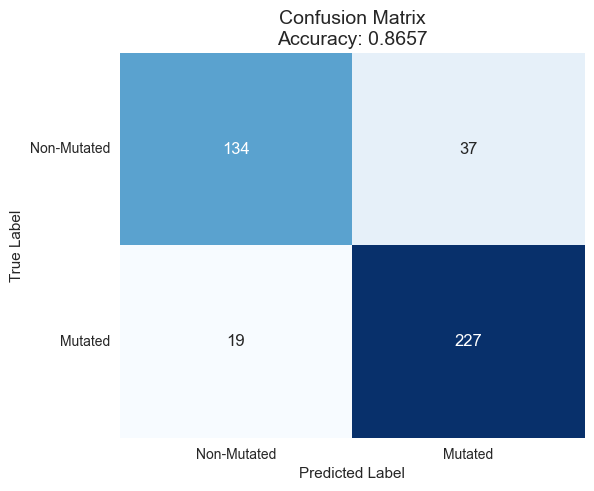

F1 Score: 0.8902
Precision: 0.8598
Recall: 0.9228
ROC AUC: 0.9080


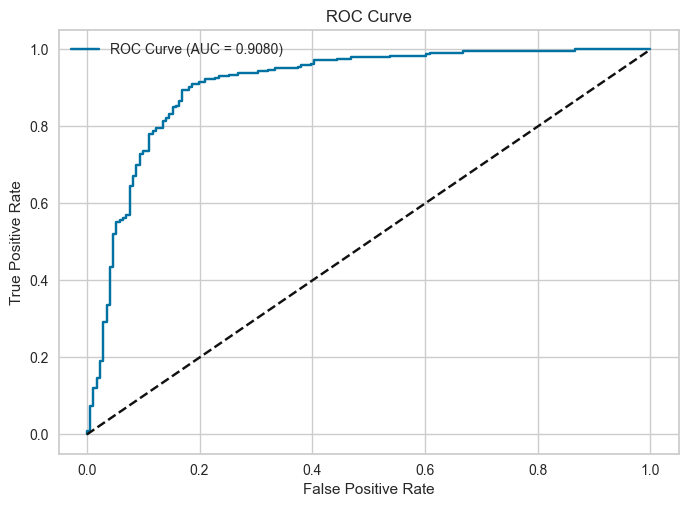


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83       171
           1       0.86      0.92      0.89       246

    accuracy                           0.87       417
   macro avg       0.87      0.85      0.86       417
weighted avg       0.87      0.87      0.86       417



In [ ]:
cm = confusion_matrix(y_test_target, y_pred_target)
acc = accuracy_score(y_test_target, y_pred_target)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.4f}', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Non-Mutated', 'Mutated'])
plt.yticks([0.5, 1.5], ['Non-Mutated', 'Mutated'], rotation=0)
plt.show()


y_pred_prob = final_model.predict_proba(X_test_targ_scaled)[:, 1]  # For ROC AUC

f1 = f1_score(y_test_target, y_pred_target)
precision = precision_score(y_test_target, y_pred_target)
recall = recall_score(y_test_target, y_pred_target)
roc_auc = roc_auc_score(y_test_target, y_pred_prob)

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# ROC Curve plot
fpr, tpr, thresholds = roc_curve(y_test_target, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_target, y_pred_target))

### **Step 3**
Same classifier but on statistically relevant genes (from differential expression analysis). We import statistically relevant genes from degs csv, we filter df on those and then apply same classifier as before.

In [19]:
degs = pd.read_csv('DEGs_filtered_sorted.csv')
degs = degs.rename(columns={'Unnamed: 0': 'ModelID'})
degs = degs.set_index('ModelID')

In [20]:
degs.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ModelID,,,,,,
SCGB1A1 (7356),3.883678,4.280461,0.558748,7.660815,1.847574e-14,3.111661e-13
KLK5 (25818),18.685852,4.085804,0.382011,10.695521,1.068179e-26,1.122585e-24
LGALS4 (3960),24.484483,3.891671,0.387099,10.053425,8.872928e-24,6.789943e-22
GRP (2922),3.226136,3.598727,0.829901,4.336335,1.448783e-05,5.157773e-05
KRT5 (3852),144.877821,3.517110,0.319169,11.019598,3.074273e-28,3.815971e-26


In [21]:
filtered_genes = expression[expression.columns.intersection(degs.index)]
y = expression['Mutation'].astype('category').cat.codes

In [22]:
filtered_genes.head()

,TSPAN6 (7105),DPM1 (8813),C1orf112 (55732),CFH (3075),GCLC (2729),STPG1 (90529),NIPAL3 (57185),LAS1L (81887),ENPP4 (22875),ANKIB1 (54467),...,AC093512.2 (112694756),ARHGAP11B (89839),POLR2J3 (548644),ASDURF (110599588),DERPC (113455421),AC055839.2 (728392),NOTCH2NLC (100996717),AP001453.3 (114841035),H3C2 (8358),DUS4L-BCAP29 (115253422)
ModelID,,,,,,,,,,,,,,,,,,,,,
ACH-001113,4.331992,7.364660,4.471187,1.226509,6.500005,3.451541,4.181103,5.035624,2.280956,5.084490,...,4.168321,1.641546,5.612352,2.981853,4.606442,2.253989,2.587365,2.179511,2.689299,2.130931
ACH-001289,4.567424,7.106641,3.504620,0.189034,4.221877,1.903038,3.257011,4.959770,3.622930,5.128046,...,4.095080,2.247928,4.733354,3.070389,4.323370,5.827057,5.428611,2.829850,1.286881,1.464668
ACH-001339,3.150560,7.379118,4.228049,1.310340,3.682573,2.881665,3.494416,4.331992,0.790772,4.078097,...,2.263034,2.056584,4.807355,1.521051,3.855990,0.594549,3.665620,1.744161,0.594549,2.946731
ACH-001979,4.240314,5.681168,1.641546,7.236301,4.596935,3.089159,5.041769,4.495056,0.000000,4.040016,...,3.415488,0.622930,4.837439,2.608809,4.703211,1.232661,2.260026,2.269033,0.000000,1.887525
ACH-002438,4.032101,6.674687,3.003602,2.169925,3.253989,2.500802,3.819668,4.471838,1.713696,4.385431,...,3.609991,1.627607,2.867896,1.773996,4.135863,2.570463,2.881665,3.452859,0.238787,1.748461


Test accuracy: 0.8568


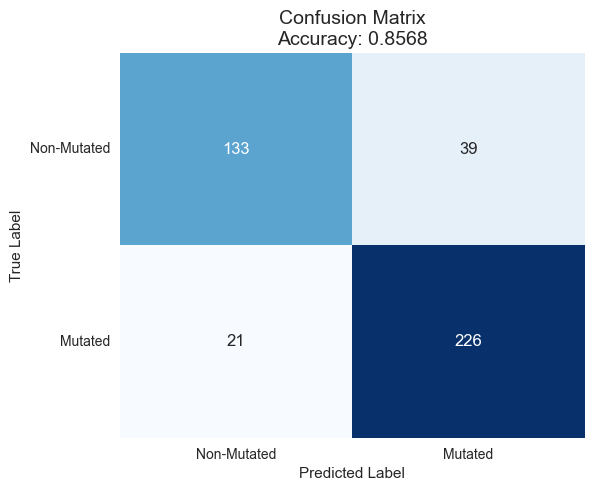

F1 Score: 0.8828
Precision: 0.8528
Recall: 0.9150
ROC AUC: 0.9185


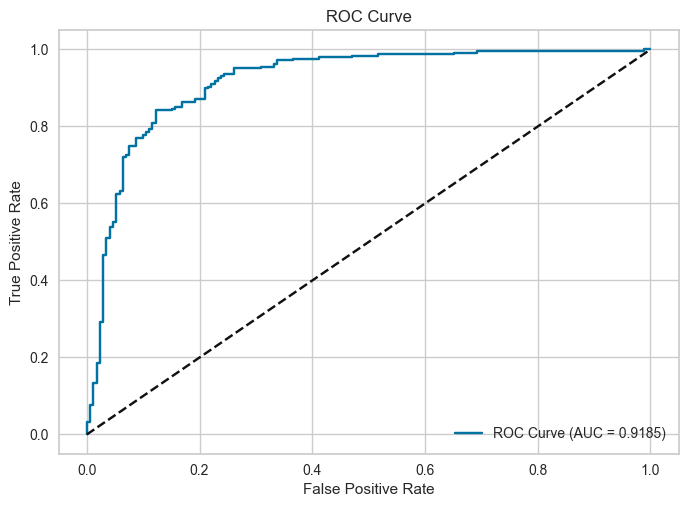


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.77      0.82       172
           1       0.85      0.91      0.88       247

    accuracy                           0.86       419
   macro avg       0.86      0.84      0.85       419
weighted avg       0.86      0.86      0.86       419



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    filtered_genes, y, test_size=0.25, random_state=43, stratify=y
)

# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

final_model = GradientBoostingClassifier(
                learning_rate=0.1,
                n_estimators=200,
                subsample=0.8,
                random_state=42
            )


final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.4f}', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Non-Mutated', 'Mutated'])
plt.yticks([0.5, 1.5], ['Non-Mutated', 'Mutated'], rotation=0)
plt.show()


y_pred_prob = final_model.predict_proba(X_test_scaled)[:, 1]  # For ROC AUC

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# ROC Curve plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

We can do the same considerations of before: the model performance is slightly worse, but the fact that the predictor is still so satisfactory despite working only on 20 features means that the features we have selected (in this case the genes that vary the most from differential expression analysis) are the right ones to select. Again, there is a clear biological interpretation behind the model, which is nice.

Performance could be further improved by:
- refining the selection of genes
- finetuning on this new filtered dataset